<a href="https://colab.research.google.com/github/CristianeAraujo88/NLP-RU-1180053/blob/main/NLP_RU_1180053.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# BLOCO 1 - INSTALAÇÃO E IMPORTAÇÃO
# =========================================================

!pip install nltk wordcloud unidecode -q

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from unidecode import unidecode
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

nltk.download('stopwords')
nltk.download('rslp')

# IDENTIFICADOR PESSOAL OBRIGATÓRIO
contador1180053 = 0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 4.9 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


In [3]:
# =========================================================
# BLOCO 2 - LEITURA DO CSV
# =========================================================

df = pd.read_csv('/content/pre-processed.csv')
print(df.head())
print(df.columns)
print(df.shape)

   index label                                  preprocessed_news
0      0  fake  katia abreu diz vai colocar expulsao moldura n...
1      1  fake  ray peita bolsonaro conservador fake entrevist...
2      2  fake  reinaldo azevedo desmascarado policia federal ...
3      3  fake  relatorio assustador bndes mostra dinheiro pub...
4      4  fake  radialista americano fala sobre pt vendem ilus...
Index(['index', 'label', 'preprocessed_news'], dtype='object')
(7200, 3)


In [4]:
# =========================================================
# BLOCO 3 - INSPECIONAR COLUNAS
# =========================================================

for col in df.columns:
    print(col)

index
label
preprocessed_news


In [5]:
# =========================================================
# BLOCO 4 - SELECIONAR COLUNAS IMPORTANTES
# =========================================================

dados = df[['preprocessed_news', 'label']].copy()

dados.columns = ['texto', 'classe']

print(dados.head())
print(dados['classe'].value_counts())

                                               texto classe
0  katia abreu diz vai colocar expulsao moldura n...   fake
1  ray peita bolsonaro conservador fake entrevist...   fake
2  reinaldo azevedo desmascarado policia federal ...   fake
3  relatorio assustador bndes mostra dinheiro pub...   fake
4  radialista americano fala sobre pt vendem ilus...   fake
classe
fake    3600
true    3600
Name: count, dtype: int64


In [6]:
# =========================================================
# BLOCO 5 - PRÉ-PROCESSAMENTO (NLTK)
# =========================================================

import re
from unidecode import unidecode
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer

stop_words = set(stopwords.words('portuguese'))
stemmer = RSLPStemmer()

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = unidecode(texto)
    texto = re.sub(r'http\S+|www\S+|https\S+', ' ', texto)
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    tokens = texto.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

dados['texto_limpo'] = dados['texto'].apply(limpar_texto)

print(dados[['texto', 'texto_limpo']].head())

                                               texto  \
0  katia abreu diz vai colocar expulsao moldura n...   
1  ray peita bolsonaro conservador fake entrevist...   
2  reinaldo azevedo desmascarado policia federal ...   
3  relatorio assustador bndes mostra dinheiro pub...   
4  radialista americano fala sobre pt vendem ilus...   

                                         texto_limpo  
0  kat abr diz vai coloc expulsa mold nao reclam ...  
1  ray peit bolsonar conserv fak entrev danil gen...  
2  reinald azeved desmascar polic feder ferrenh c...  
3  relatori assust bnd mostr dinh publ brasil jor...  
4  radial americ fal sobr vend ilusa pov brasil p...  


In [30]:
# =========================================================
# BLOCO 6 - NORMALIZAÇÃO DOS TEXTOS
# =========================================================

def truncar_texto(texto, max_palavras=80):
    tokens = texto.split()
    return ' '.join(tokens[:max_palavras])

dados['texto_final'] = dados['texto_limpo'].apply(lambda x: truncar_texto(x, 80))

print(dados[['texto_limpo', 'texto_final']].head())

                                         texto_limpo  \
0  kat abr diz vai coloc expulsa mold nao reclam ...   
1  ray peit bolsonar conserv fak entrev danil gen...   
2  reinald azeved desmascar polic feder ferrenh c...   
3  relatori assust bnd mostr dinh publ brasil jor...   
4  radial americ fal sobr vend ilusa pov brasil p...   

                                         texto_final  
0  kat abr diz vai coloc expulsa mold nao reclam ...  
1  ray peit bolsonar conserv fak entrev danil gen...  
2  reinald azeved desmascar polic feder ferrenh c...  
3  relatori assust bnd mostr dinh publ brasil jor...  
4  radial americ fal sobr vend ilusa pov brasil p...  


In [31]:
# =========================================================
# BLOCO 7 - DIVISÃO TREINO / TESTE
# =========================================================

from sklearn.model_selection import train_test_split

X = dados['texto_final']
y = dados['classe']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 5400
Teste: 1800


In [36]:
# =========================================================
# BLOCO 8 - TF-IDF AJUSTADO
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,1),
    min_df=5,
    max_df=0.9
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Total de termos:", len(vectorizer.get_feature_names_out()))

Total de termos: 5246


In [37]:
# =========================================================
# BLOCO 9 - MODELO
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

modelo = LogisticRegression(max_iter=2000)
modelo.fit(X_train_tfidf, y_train)

y_pred = modelo.predict(X_test_tfidf)

acuracia = accuracy_score(y_test, y_pred)

print("ACURÁCIA:", acuracia)

ACURÁCIA: 0.8822222222222222


In [38]:
# =========================================================
# BLOCO 10 - CONTAGEM DOS TERMOS
# =========================================================

features = vectorizer.get_feature_names_out()

unigramas = [f for f in features if len(f.split()) == 1]
bigramas = [f for f in features if len(f.split()) == 2]
trigramas = [f for f in features if len(f.split()) == 3]

print("Quantidade de palavras (unigramas):", len(unigramas))
print("Quantidade de bigramas:", len(bigramas))
print("Quantidade de trigramas:", len(trigramas))
print("Total geral:", len(features))

Quantidade de palavras (unigramas): 5246
Quantidade de bigramas: 0
Quantidade de trigramas: 0
Total geral: 5246


In [39]:
# =========================================================
# BLOCO 11 - TERMOS MAIS IMPORTANTES
# =========================================================

import numpy as np

nomes_features = np.array(vectorizer.get_feature_names_out())
coeficientes = modelo.coef_[0]

print("Classes do modelo:", modelo.classes_)

# assumindo ordem alfabética: fake, true
top_true_idx = np.argsort(coeficientes)[-100:]
top_fake_idx = np.argsort(coeficientes)[:100]

top_true = dict(zip(nomes_features[top_true_idx], coeficientes[top_true_idx]))
top_fake = dict(zip(nomes_features[top_fake_idx], np.abs(coeficientes[top_fake_idx])))

print("Exemplo termos TRUE:", list(top_true.items())[:10])
print("Exemplo termos FAKE:", list(top_fake.items())[:10])

Classes do modelo: ['fake' 'true']
Exemplo termos TRUE: [('apes', np.float64(1.0384958751124262)), ('pass', np.float64(1.0395310127414854)), ('manh', np.float64(1.0477382997256166)), ('comentari', np.float64(1.0492365097331078)), ('pont', np.float64(1.0550441911207011)), ('mudanc', np.float64(1.0615440113631438)), ('outubr', np.float64(1.062305307718117)), ('previdenc', np.float64(1.0646742372622828)), ('dua', np.float64(1.0651315424417953)), ('caravan', np.float64(1.0651980018425213))]
Exemplo termos FAKE: [('dilm', np.float64(3.902898132893195)), ('lul', np.float64(3.1870322762126566)), ('hoj', np.float64(3.101040988604101)), ('diss', np.float64(3.0019838621802983)), ('atrav', np.float64(2.7793239855462404)), ('inform', np.float64(2.4595262115296563)), ('glob', np.float64(2.1106100423001615)), ('pov', np.float64(2.0830369129813975)), ('acord', np.float64(2.0780080354570143)), ('ont', np.float64(1.9947791970142412))]


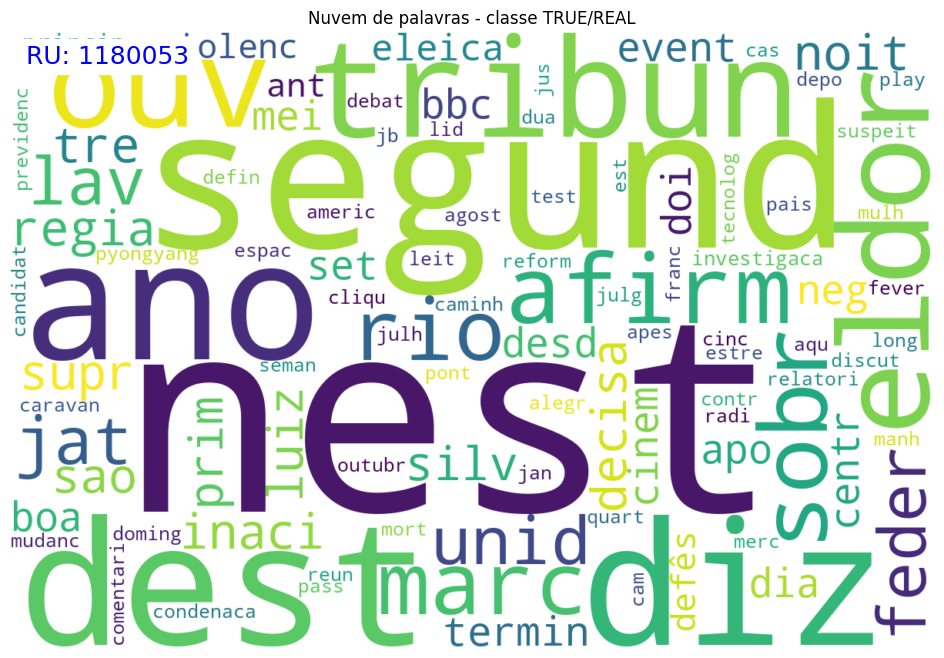

In [45]:
# =========================================================
# BLOCO 12 - NUVEM TRUE / REAL
# =========================================================

from wordcloud import WordCloud
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
wc_true = WordCloud(
    width=1200,
    height=800,
    background_color='white'
).generate_from_frequencies(top_true)

plt.imshow(wc_true, interpolation='bilinear')
plt.axis('off')
plt.text(20, 40, 'RU: 1180053', fontsize=18, color='blue', backgroundcolor='white')
plt.title('Nuvem de palavras - classe TRUE/REAL')
plt.show()

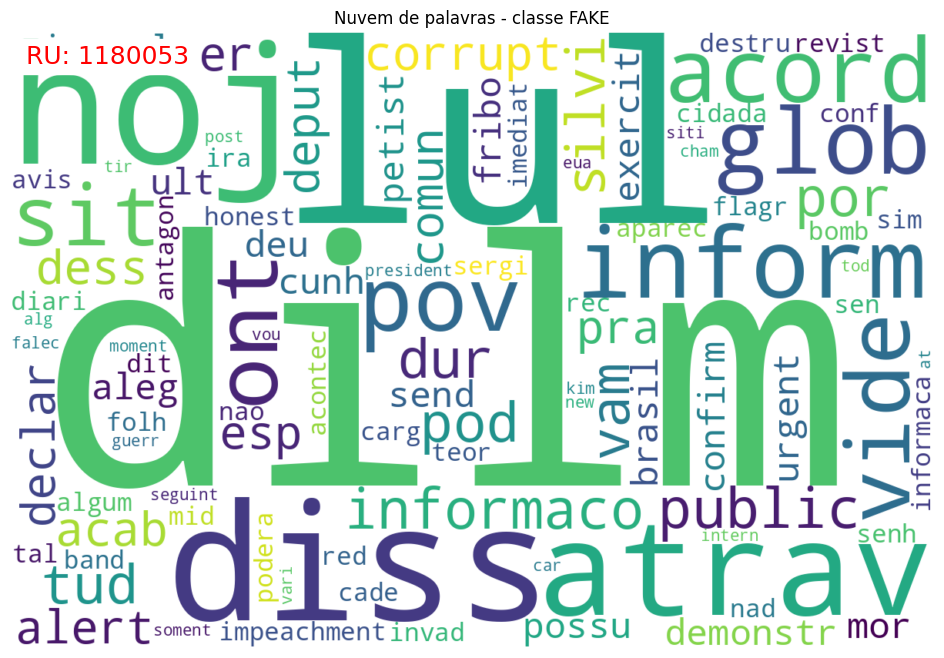

In [44]:
# =========================================================
# BLOCO 13 - NUVEM FAKE
# =========================================================

plt.figure(figsize=(12,8))
wc_fake = WordCloud(
    width=1200,
    height=800,
    background_color='white'
).generate_from_frequencies(top_fake)

plt.imshow(wc_fake, interpolation='bilinear')
plt.axis('off')
plt.text(20, 40, 'RU: 1180053', fontsize=18, color='red', backgroundcolor='white')
plt.title('Nuvem de palavras - classe FAKE')
plt.show()